# Data Preprocessing
## Import Libraries

In [1]:
# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots within the notebook
%matplotlib inline

# Improve plot appearance
sns.set_style("whitegrid")


# Ignore Warning Messages

import warnings
warnings.filterwarnings("ignore")

# Scikit-learn Preprocessing

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Feature Selection

from boruta import BorutaPy

# Machine Learning Algorithms

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from xgboost import XGBClassifier

# Model Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

# Cross Validation

from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

# Explainable AI

import shap

# Save Models

import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Load dataset
df = pd.read_csv("CKD_NHANES_2021_2023.csv")

In [3]:
df.head() # Display first five rows

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,...,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,...,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,...,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,...,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


In [4]:
df.tail() # Display last five rows

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
11928,142306.0,9.0,Male,Other Hispanic,NaN,2.01,15.4,25.3,128.0,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
11929,142307.0,49.0,Female,Non-Hispanic Black,5.0,NaN,NaN,NaN,143.8,127.0,...,6.31,6.78,1.0,2.0,1.0,1.0,3.0,91.64,No CKD,0
11930,142308.0,50.0,Male,Other Hispanic,4.0,1.95,26.4,79.3,173.3,106.0,...,6.98,4.03,2.0,NaN,NaN,2.0,NaN,NaN,Unknown,1
11931,142309.0,40.0,Male,Other Hispanic,4.0,3.11,25.5,81.9,179.1,127.0,...,9.27,3.65,2.0,NaN,NaN,2.0,NaN,92.03,No CKD,0
11932,142310.0,80.0,Female,Non-Hispanic White,3.0,5.00,27.6,72.1,161.7,128.0,...,7.15,14.90,2.0,NaN,NaN,1.0,3.0,56.28,Stage 3a (Mild-Moderate),1


In [5]:
# Dataset shape
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 11933
Number of Columns: 29


In [6]:
df.columns # Column names

Index(['participant_id', 'age', 'gender', 'ethnicity', 'education_level',
       'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic',
       'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen',
       'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid',
       'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio',
       'diabetes_diagnosed', 'insulin_use', 'diabetes_pills', 'ever_smoked',
       'current_smoker', 'egfr', 'ckd_stage', 'ckd_present'],
      dtype='object')

In [7]:
df.info() # Dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            11933 non-null  float64
 1   age                       11933 non-null  float64
 2   gender                    11933 non-null  object 
 3   ethnicity                 11933 non-null  object 
 4   education_level           7794 non-null   float64
 5   poverty_income_ratio      9892 non-null   float64
 6   bmi                       8471 non-null   float64
 7   weight_kg                 8754 non-null   float64
 8   height_cm                 8499 non-null   float64
 9   bp_systolic               7517 non-null   float64
 10  bp_diastolic              7517 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6326 non-null   float64
 13  albumin_serum             6366 non-null   float64
 14  phosph

In [8]:
# Summary Statistics for Numerical Variable

df.describe().T 

,count,mean,std,min,25%,50%,75%,max
participant_id,11933.0,136344.000000,3444.904716,1.303780e+05,133361.0000,136344.00,139327.00,142310.00
age,11933.0,38.317858,25.601990,5.397605e-79,13.0000,37.00,62.00,80.00
education_level,7794.0,3.804978,1.153750,1.000000e+00,3.0000,4.00,5.00,9.00
poverty_income_ratio,9892.0,2.708174,1.670119,5.397605e-79,1.1800,2.50,4.50,5.00
bmi,8471.0,27.246665,8.137781,1.110000e+01,21.6000,26.40,31.70,74.80
weight_kg,8754.0,70.549037,30.389021,2.700000e+00,54.2000,71.70,89.10,248.20
height_cm,8499.0,159.664549,19.864943,7.910000e+01,154.4000,163.60,172.10,200.70
bp_systolic,7517.0,119.288546,18.561052,6.100000e+01,106.0000,117.00,130.00,232.00
bp_diastolic,7517.0,72.748038,11.895572,3.300000e+01,64.0000,72.00,80.00,142.00
serum_creatinine,6326.0,0.872828,0.385498,3.300000e-01,0.7000,0.83,0.98,15.17


In [9]:
# Summary statistics for all columns (Including Categorical Variables)

df.describe(include='all').T 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
participant_id,11933.0,NaN,NaN,NaN,136344.0,3444.904716,130378.0,133361.0,136344.0,139327.0,142310.0
age,11933.0,NaN,NaN,NaN,38.317858,25.60199,0.0,13.0,37.0,62.0,80.0
gender,11933,2,Female,6358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,11933,6,Non-Hispanic White,6217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,7794.0,NaN,NaN,NaN,3.804978,1.15375,1.0,3.0,4.0,5.0,9.0
poverty_income_ratio,9892.0,NaN,NaN,NaN,2.708174,1.670119,0.0,1.18,2.5,4.5,5.0
bmi,8471.0,NaN,NaN,NaN,27.246665,8.137781,11.1,21.6,26.4,31.7,74.8
weight_kg,8754.0,NaN,NaN,NaN,70.549037,30.389021,2.7,54.2,71.7,89.1,248.2
height_cm,8499.0,NaN,NaN,NaN,159.664549,19.864943,79.1,154.4,163.6,172.1,200.7
bp_systolic,7517.0,NaN,NaN,NaN,119.288546,18.561052,61.0,106.0,117.0,130.0,232.0


In [10]:
# Dataset Dimension

print(f"Number of observations : {df.shape[0]}")
print(f"Number of variables    : {df.shape[1]}")

Number of observations : 11933
Number of variables    : 29


In [11]:
# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print(f"Numerical Features   : {len(numerical_columns)}")
print(f"Categorical Features : {len(categorical_columns)}")

Numerical Features   : 26
Categorical Features : 3


In [12]:
print("Numerical Features:")
print(numerical_columns.tolist())

Numerical Features:
['participant_id', 'age', 'education_level', 'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic', 'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'insulin_use', 'diabetes_pills', 'ever_smoked', 'current_smoker', 'egfr', 'ckd_present']


In [13]:
print("Categorical Features:")
print(categorical_columns.tolist())

Categorical Features:
['gender', 'ethnicity', 'ckd_stage']


In [14]:
constant_columns = [
    col for col in df.columns
    if df[col].nunique() == 1
]

print("Constant Columns:")
print(constant_columns)

Constant Columns:
[]


In [15]:
unique_values = pd.DataFrame({
    "Feature": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

unique_values.sort_values(by="Unique Values")

,Feature,Unique Values
2,gender,2
22,insulin_use,2
28,ckd_present,2
25,current_smoker,3
23,diabetes_pills,3
21,diabetes_diagnosed,4
24,ever_smoked,4
3,ethnicity,6
4,education_level,6
27,ckd_stage,8


In [16]:
# Missing Values Count

missing_values = df.isnull().sum()

missing_values

participant_id                  0
age                             0
gender                          0
ethnicity                       0
education_level              4139
poverty_income_ratio         2041
bmi                          3462
weight_kg                    3179
height_cm                    3434
bp_systolic                  4416
bp_diastolic                 4416
serum_creatinine             5607
blood_urea_nitrogen          5607
albumin_serum                5567
phosphorus                   5611
bicarbonate                  5608
calcium                      5571
uric_acid                    5604
urine_creatinine             3779
urine_albumin                3780
albumin_creatinine_ratio     3780
diabetes_diagnosed            193
insulin_use                 10852
diabetes_pills               9652
ever_smoked                  3798
current_smoker               8690
egfr                         5607
ckd_stage                       0
ckd_present                     0
dtype: int64

In [17]:
# Missing value percentages

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

missing_df.sort_values(by='Missing Percentage', ascending=False)

,Missing Count,Missing Percentage
insulin_use,10852,90.941088
diabetes_pills,9652,80.884941
current_smoker,8690,72.823263
phosphorus,5611,47.020867
bicarbonate,5608,46.995726
blood_urea_nitrogen,5607,46.987346
serum_creatinine,5607,46.987346
egfr,5607,46.987346
uric_acid,5604,46.962206
calcium,5571,46.685662


In [18]:
# Display only columns containing missing values

missing_df = missing_df[missing_df['Missing Count'] > 0]

missing_df.sort_values(by='Missing Percentage', ascending=False)

,Missing Count,Missing Percentage
insulin_use,10852,90.941088
diabetes_pills,9652,80.884941
current_smoker,8690,72.823263
phosphorus,5611,47.020867
bicarbonate,5608,46.995726
egfr,5607,46.987346
blood_urea_nitrogen,5607,46.987346
serum_creatinine,5607,46.987346
uric_acid,5604,46.962206
calcium,5571,46.685662


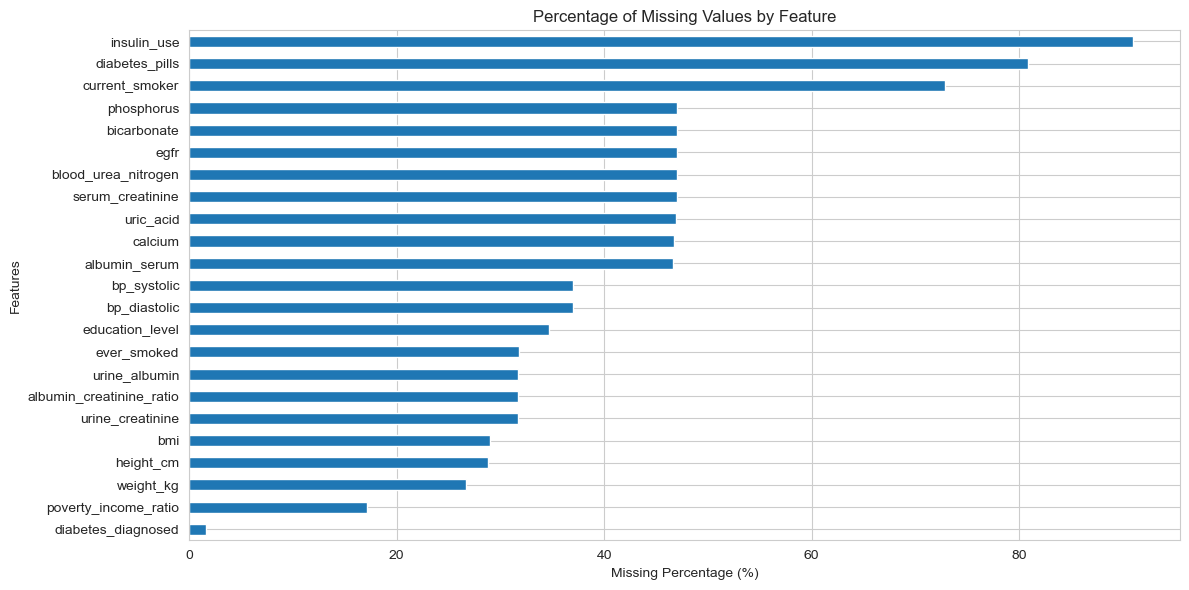

In [19]:
plt.figure(figsize=(12,6))

missing_df['Missing Percentage'].sort_values().plot(kind='barh')

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

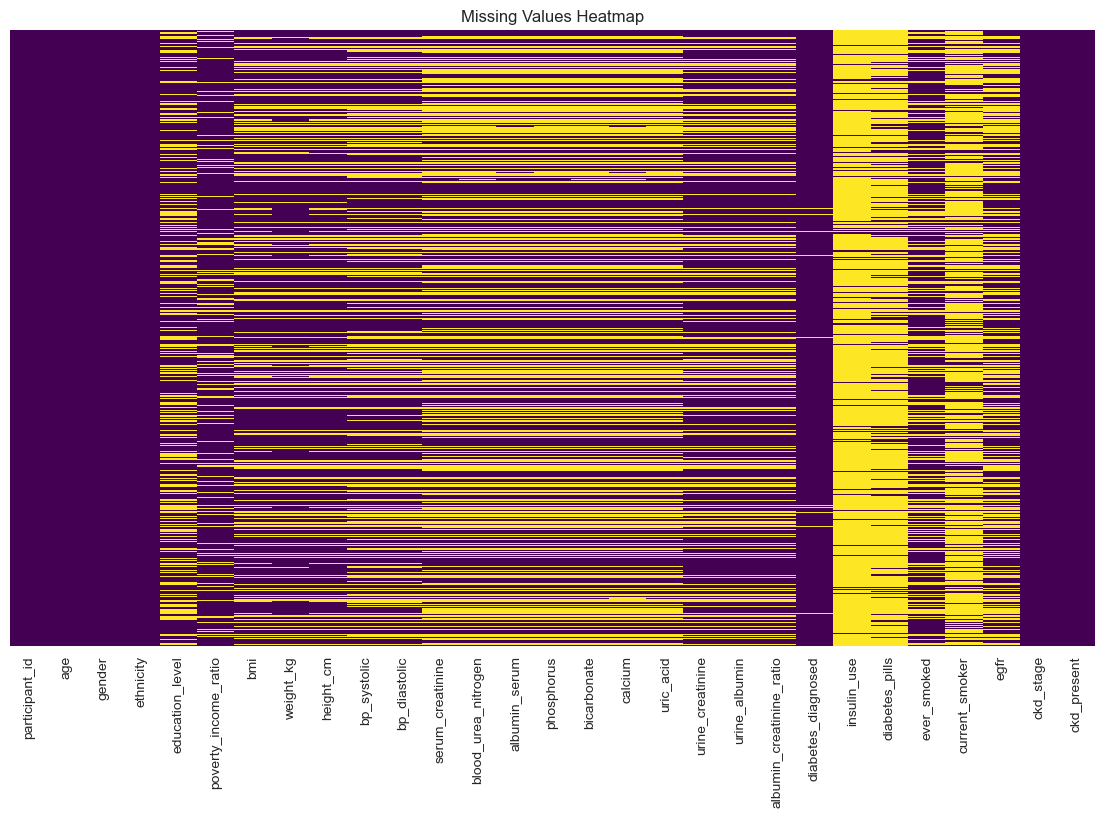

In [20]:
plt.figure(figsize=(14,8))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis',
            yticklabels=False)

plt.title("Missing Values Heatmap")

plt.show()

In [21]:
total_missing = df.isnull().sum().sum()

print(f"Total Missing Values: {total_missing}")

print(f"Percentage Missing: {(total_missing / df.size) * 100:.2f}%")

Total Missing Values: 114393
Percentage Missing: 33.06%


In [22]:
# Check Duplicate Rows

duplicate_rows = df.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicate_rows}")

Number of Duplicate Rows: 0


In [23]:
# Target Variable Distribution

df['ckd_present'].value_counts()

ckd_present
1    8341
0    3592
Name: count, dtype: int64

In [24]:
df['ckd_present'].value_counts(normalize=True) * 100

ckd_present
1    69.898601
0    30.101399
Name: proportion, dtype: float64

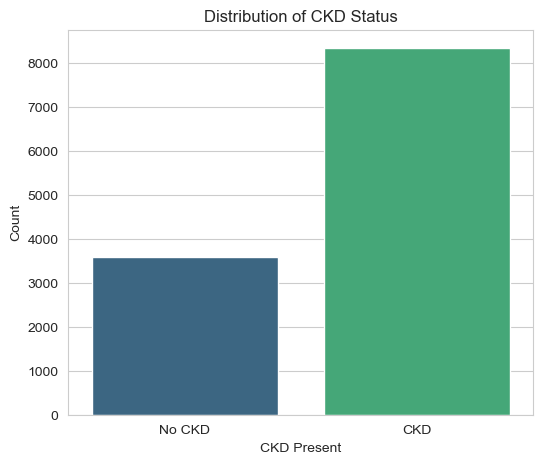

In [25]:
plt.figure(figsize=(6, 5))

sns.countplot(data=df, x='ckd_present', palette='viridis')

plt.title("Distribution of CKD Status")
plt.xlabel("CKD Present")
plt.ylabel("Count")

plt.xticks([0, 1], ["No CKD", "CKD"])

plt.show()

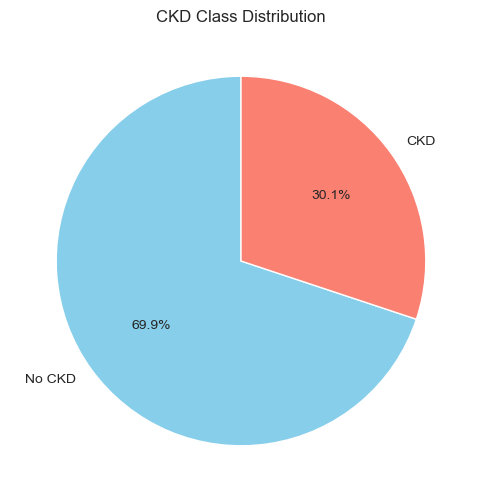

In [26]:
plt.figure(figsize=(6, 6))

df['ckd_present'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['No CKD', 'CKD'],
    startangle=90,
    colors=['skyblue', 'salmon']
)

plt.ylabel("")
plt.title("CKD Class Distribution")

plt.show()

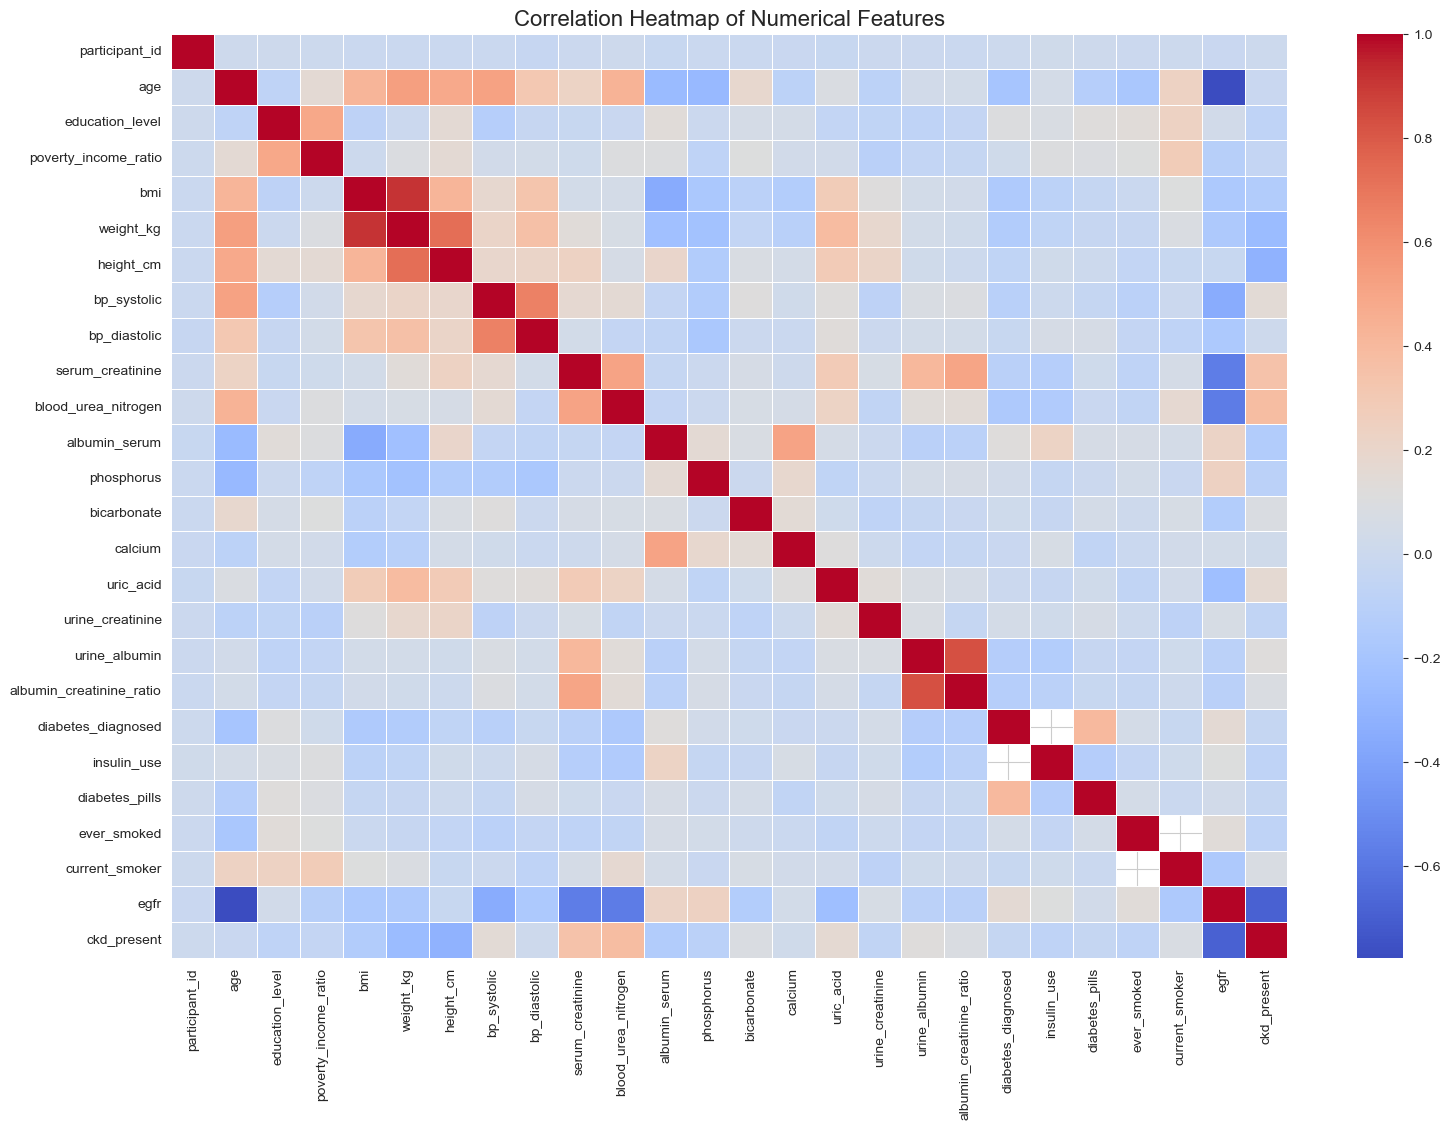

In [27]:
# Correlation Heatmap

plt.figure(figsize=(18, 12))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)

plt.show()

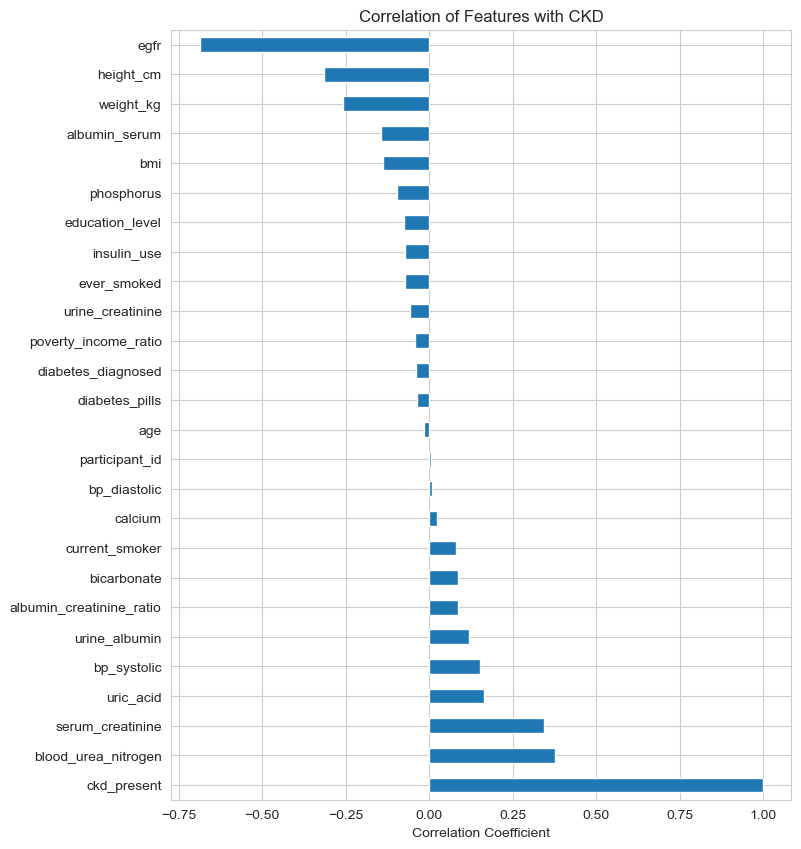

ckd_present                 1.000000
blood_urea_nitrogen         0.376539
serum_creatinine            0.342947
uric_acid                   0.163093
bp_systolic                 0.152682
urine_albumin               0.119813
albumin_creatinine_ratio    0.086244
bicarbonate                 0.085214
current_smoker              0.079362
calcium                     0.022999
bp_diastolic                0.008765
participant_id              0.005938
age                        -0.015352
diabetes_pills             -0.036836
diabetes_diagnosed         -0.039825
poverty_income_ratio       -0.043473
urine_creatinine           -0.056182
ever_smoked                -0.071377
insulin_use                -0.074015
education_level            -0.074249
phosphorus                 -0.095586
bmi                        -0.139227
albumin_serum              -0.143627
weight_kg                  -0.258702
height_cm                  -0.316080
egfr                       -0.687409
Name: ckd_present, dtype: float64


In [28]:
# Correlation with target variable

target_corr = correlation_matrix["ckd_present"].sort_values(ascending=False)

plt.figure(figsize=(8,10))

target_corr.plot(kind="barh")

plt.title("Correlation of Features with CKD")

plt.xlabel("Correlation Coefficient")

plt.show()

print(target_corr)

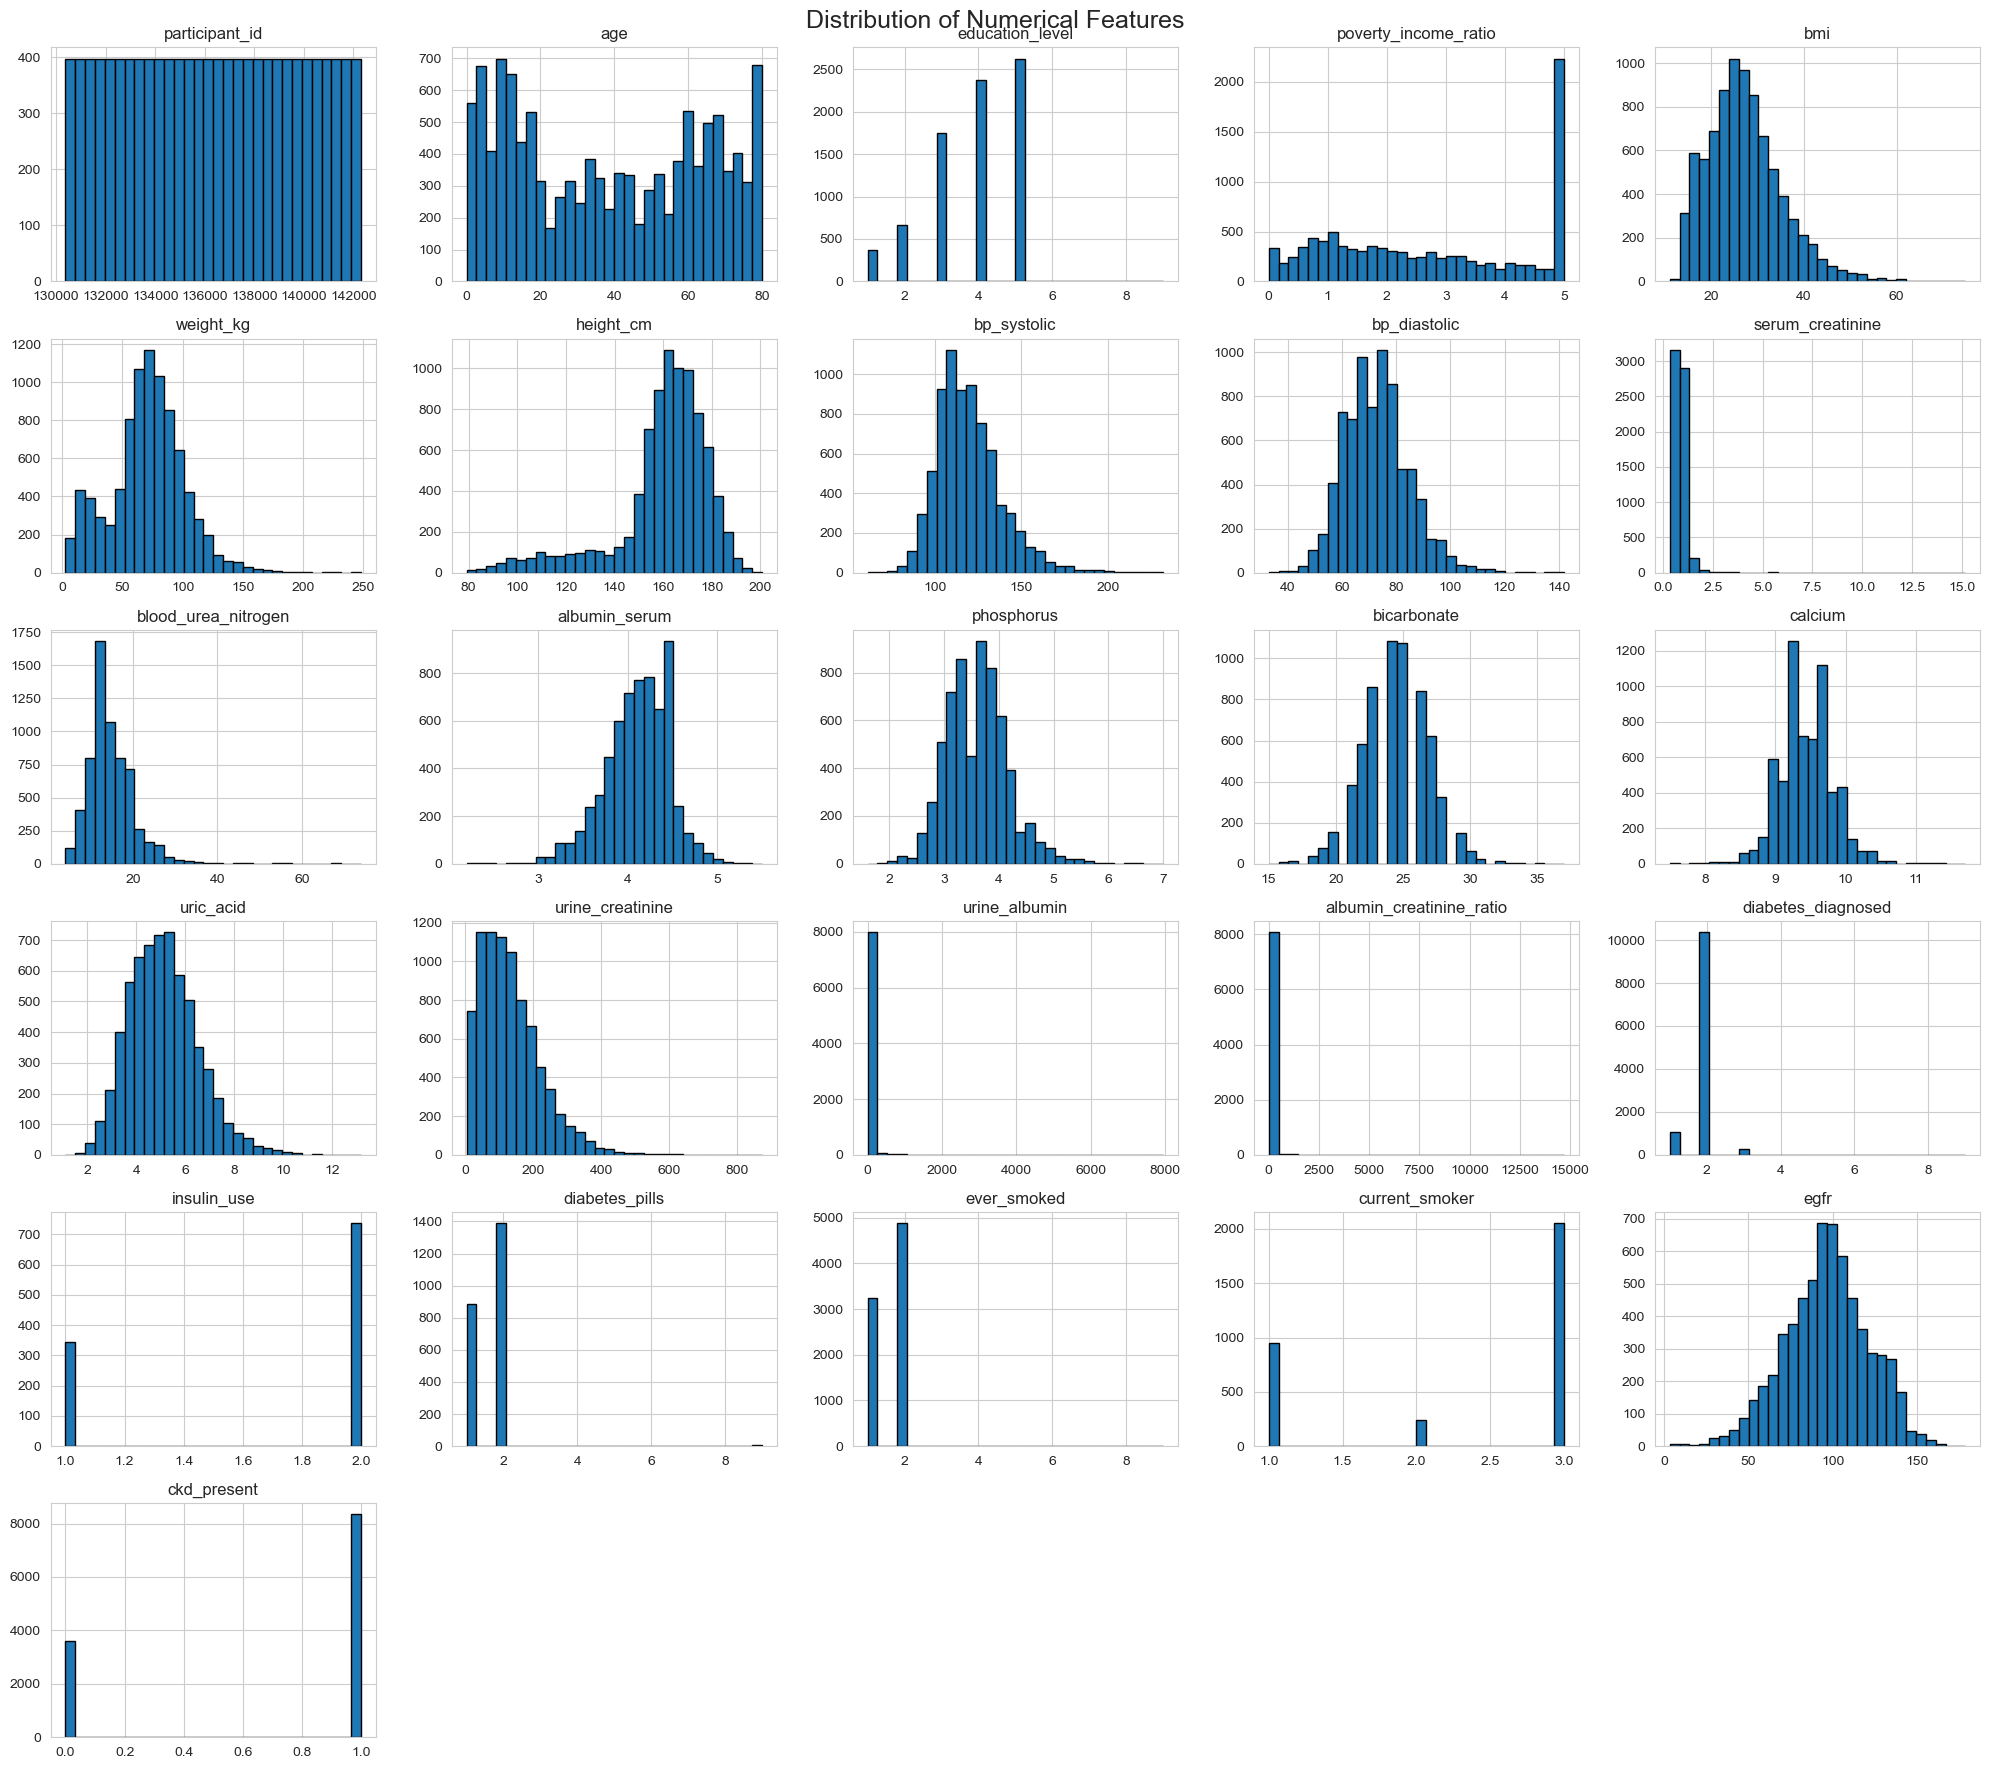

In [29]:
# Histograms

df.hist(
    figsize=(20,18),
    bins=30,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.tight_layout()

plt.show()

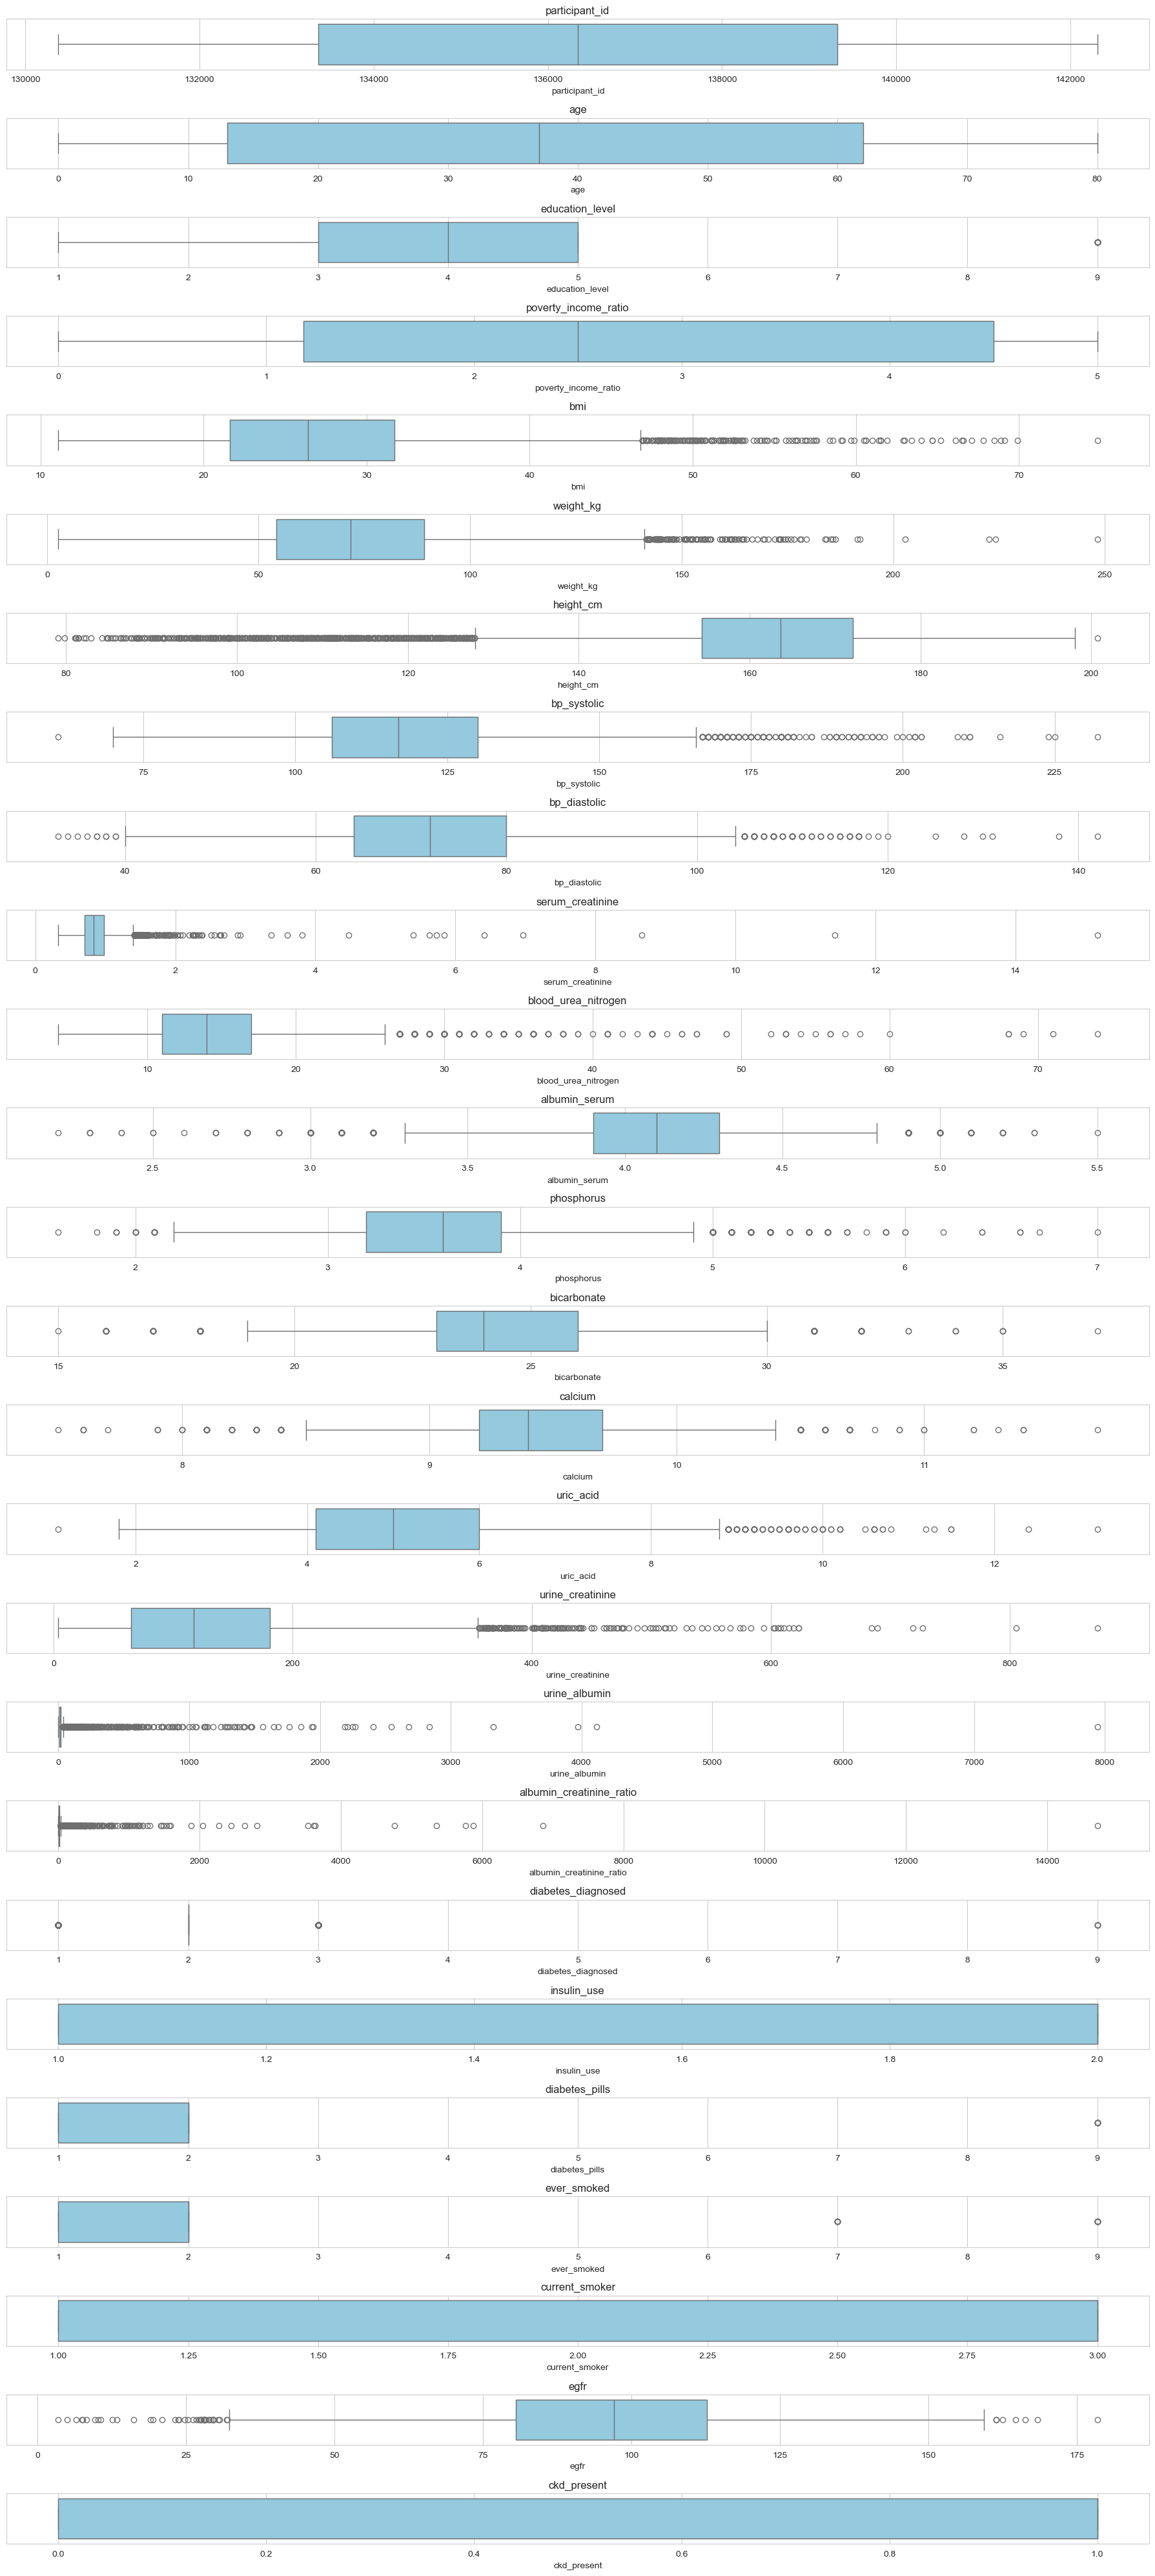

In [30]:
# Boxplots (Outlier detection)

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18, 40))

for i, column in enumerate(numerical_columns):

    plt.subplot(len(numerical_columns), 1, i+1)

    sns.boxplot(
        x=df[column],
        color="skyblue"
    )

    plt.title(column)

plt.tight_layout()

plt.show()

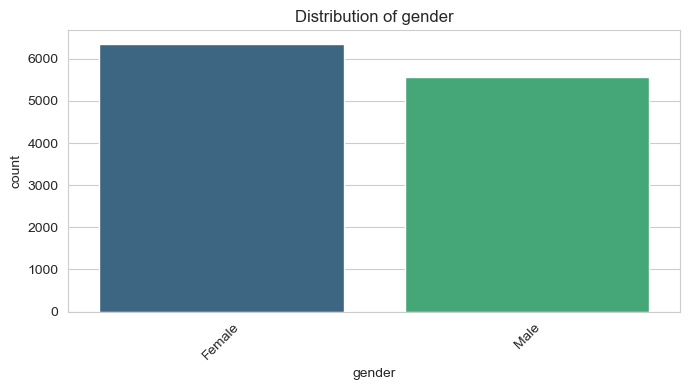

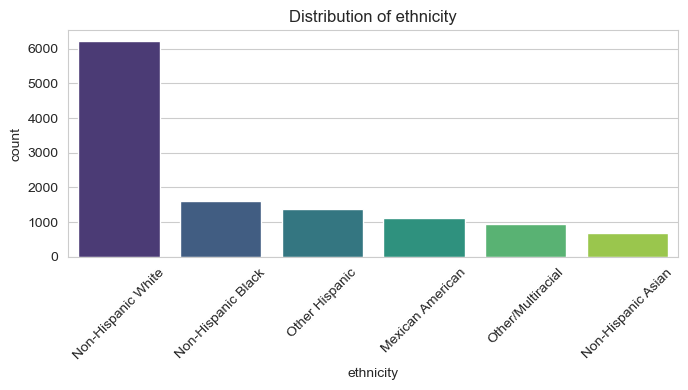

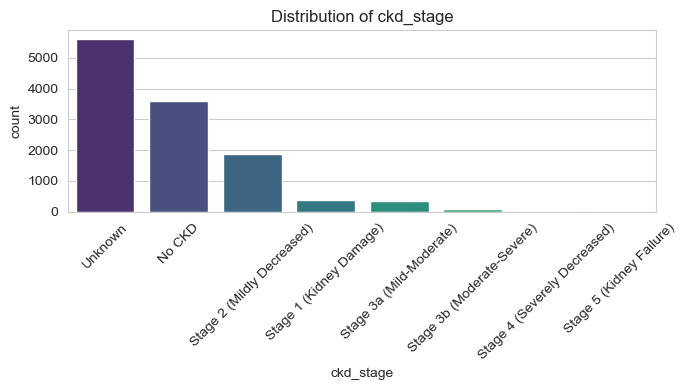

In [31]:
categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index,
        palette="viridis"
    )

    plt.title(f"Distribution of {column}")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

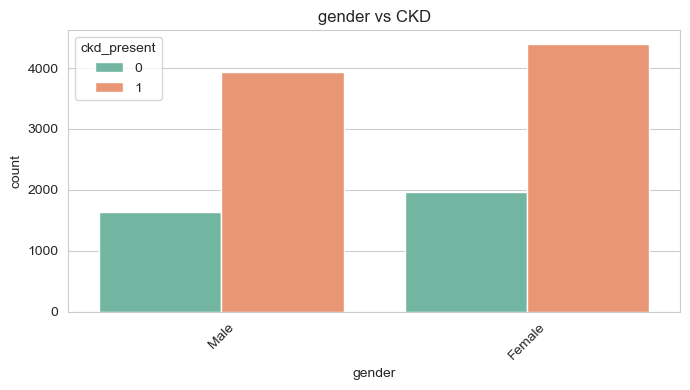

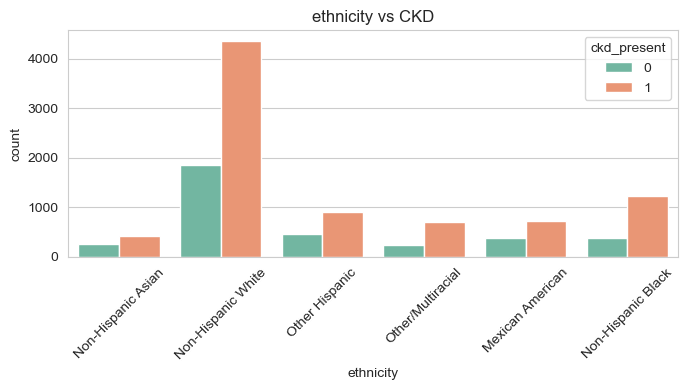

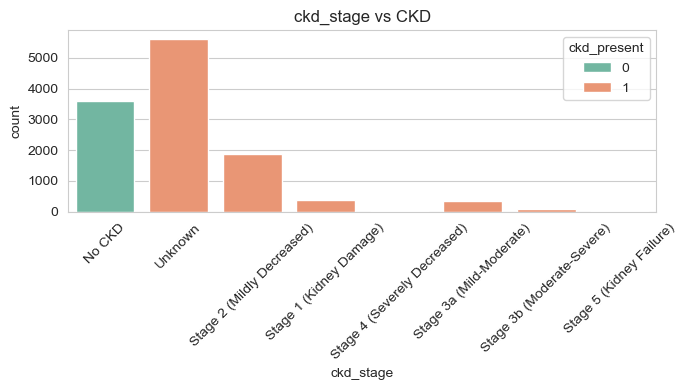

In [32]:
for column in categorical_columns:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=column,
        hue="ckd_present",
        palette="Set2"
    )

    plt.title(f"{column} vs CKD")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

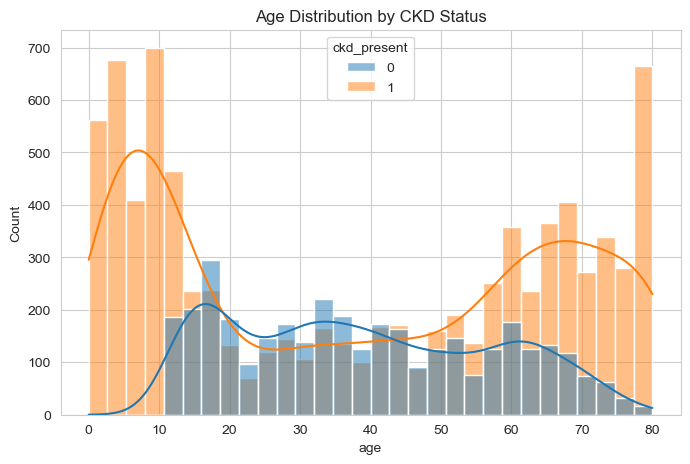

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    hue="ckd_present",
    kde=True,
    bins=30
)

plt.title("Age Distribution by CKD Status")

plt.show()

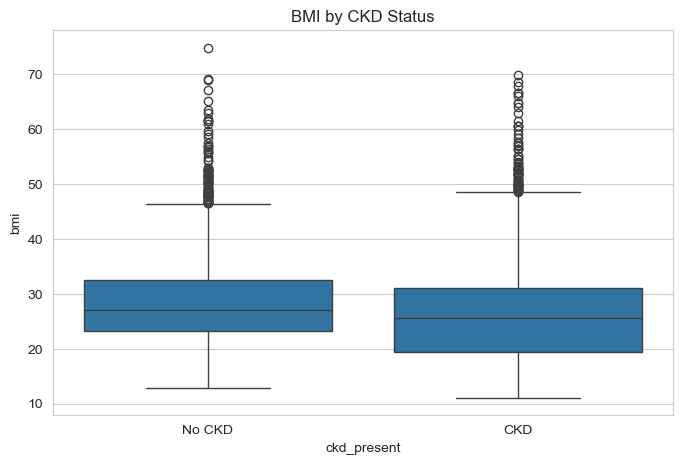

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="ckd_present",
    y="bmi"
)

plt.xticks([0,1],["No CKD","CKD"])

plt.title("BMI by CKD Status")

plt.show()

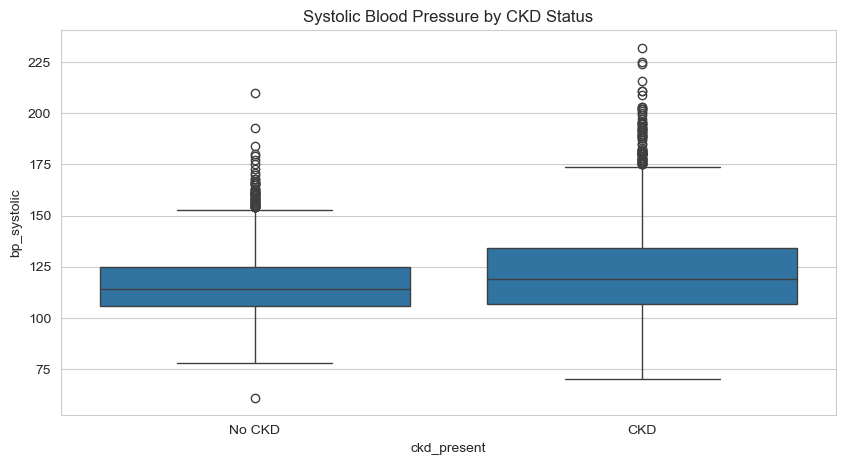

In [35]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="ckd_present",
    y="bp_systolic"
)

plt.xticks([0,1],["No CKD","CKD"])

plt.title("Systolic Blood Pressure by CKD Status")

plt.show()

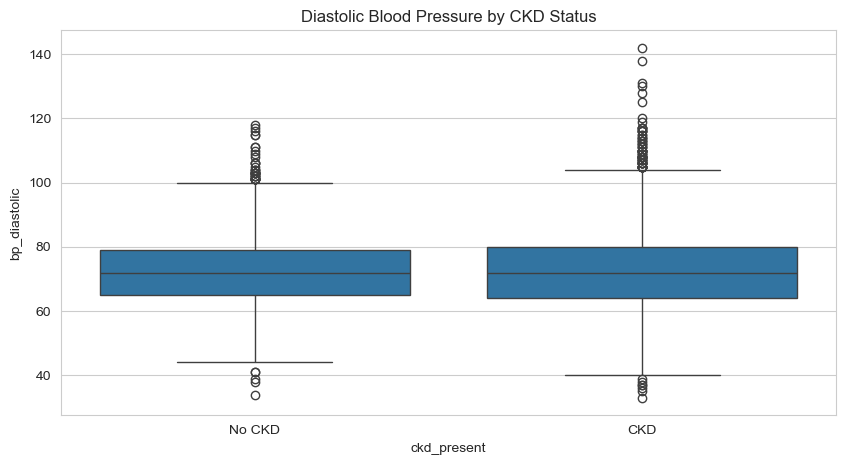

In [36]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="ckd_present",
    y="bp_diastolic"
)

plt.xticks([0,1],["No CKD","CKD"])

plt.title("Diastolic Blood Pressure by CKD Status")

plt.show()

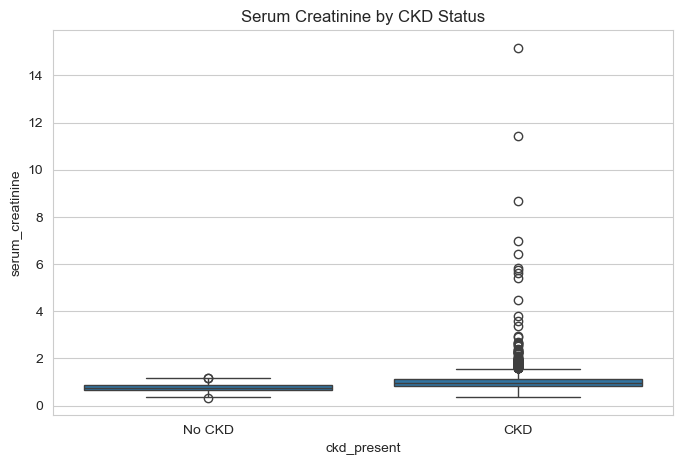

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="ckd_present",
    y="serum_creatinine"
)

plt.xticks([0,1],["No CKD","CKD"])

plt.title("Serum Creatinine by CKD Status")

plt.show()

## Data Cleaning

In [38]:
# Remove Unnecessary Columns

columns_to_drop = [
    "participant_id",
    "ckd_stage"
]

df = df.drop(columns=columns_to_drop)

print("Remaining Features:", df.shape[1])
df.head()

Remaining Features: 27


,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,...,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_present
0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,98.0,...,136.0,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,0
1,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,84.0,...,64.0,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,0
2,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,79.0,...,157.0,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,0
3,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,NaN,...,208.0,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,1
4,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,NaN,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,1


In [39]:
# Drop Features with excessive missing values

high_missing_columns = [
    "insulin_use",
    "diabetes_pills",
    "current_smoker"
]

df = df.drop(columns=high_missing_columns)

print(df.shape)

(11933, 24)


In [40]:
# Separate features and target

X = df.drop("ckd_present", axis=1)
y = df["ckd_present"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (11933, 23)
Target Shape: (11933,)


In [41]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical Features")
print(numerical_columns)

print("\nCategorical Features")
print(categorical_columns)

Numerical Features
['age', 'education_level', 'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic', 'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'ever_smoked', 'egfr']

Categorical Features
['gender', 'ethnicity']


In [42]:
for column in categorical_columns:
    le = LabelEncoder()
    le.fit(X[column].astype(str))

    print(f"\n{column}")
    print(dict(zip(le.classes_, le.transform(le.classes_))))


gender
{'Female': np.int64(0), 'Male': np.int64(1)}

ethnicity
{'Mexican American': np.int64(0), 'Non-Hispanic Asian': np.int64(1), 'Non-Hispanic Black': np.int64(2), 'Non-Hispanic White': np.int64(3), 'Other Hispanic': np.int64(4), 'Other/Multiracial': np.int64(5)}


In [43]:
label_encoder = LabelEncoder()

# Encode each categorical column
for column in categorical_columns:
    X[column] = label_encoder.fit_transform(X[column].astype(str))

In [44]:
# Check the first five rows
X.head()

,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,...,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,ever_smoked,egfr
0,43.0,1,1,5.0,5.00,27.0,86.9,179.5,135.0,98.0,...,3.7,24.0,9.6,5.1,136.0,23.12,17.00,2.0,1.0,112.61
1,66.0,1,3,5.0,5.00,33.5,101.8,174.2,121.0,84.0,...,3.2,25.0,9.4,8.5,64.0,4.25,6.64,2.0,1.0,97.98
2,44.0,0,4,3.0,1.41,29.7,69.4,152.9,111.0,79.0,...,3.8,25.0,9.4,4.4,157.0,12.43,7.92,1.0,2.0,111.69
3,5.0,0,5,NaN,1.53,23.8,34.3,120.1,NaN,NaN,...,NaN,NaN,NaN,NaN,208.0,16.12,7.75,2.0,NaN,NaN
4,2.0,1,3,NaN,3.60,NaN,13.6,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN


In [45]:
# Check data types
X.dtypes

age                         float64
gender                        int64
ethnicity                     int64
education_level             float64
poverty_income_ratio        float64
bmi                         float64
weight_kg                   float64
height_cm                   float64
bp_systolic                 float64
bp_diastolic                float64
serum_creatinine            float64
blood_urea_nitrogen         float64
albumin_serum               float64
phosphorus                  float64
bicarbonate                 float64
calcium                     float64
uric_acid                   float64
urine_creatinine            float64
urine_albumin               float64
albumin_creatinine_ratio    float64
diabetes_diagnosed          float64
ever_smoked                 float64
egfr                        float64
dtype: object

In [46]:
# Missing Values Before Imputation

print("Missing Values Before Imputation")
print(X.isnull().sum().sort_values(ascending=False))

Missing Values Before Imputation
phosphorus                  5611
bicarbonate                 5608
serum_creatinine            5607
blood_urea_nitrogen         5607
egfr                        5607
uric_acid                   5604
calcium                     5571
albumin_serum               5567
bp_systolic                 4416
bp_diastolic                4416
education_level             4139
ever_smoked                 3798
albumin_creatinine_ratio    3780
urine_albumin               3780
urine_creatinine            3779
bmi                         3462
height_cm                   3434
weight_kg                   3179
poverty_income_ratio        2041
diabetes_diagnosed           193
gender                         0
ethnicity                      0
age                            0
dtype: int64


In [47]:
# Identify numerical and categorical columns

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = X.select_dtypes(include=["object"]).columns

print("Numerical Columns:", len(numerical_columns))
print("Categorical Columns:", len(categorical_columns))

Numerical Columns: 23
Categorical Columns: 0


In [48]:
# Check original values for diabetes and smoking

print("Diabetes Diagnosed values:")
print(X["diabetes_diagnosed"].unique())
print(X["diabetes_diagnosed"].value_counts(dropna=False))

print("\nEver Smoked values:")
print(X["ever_smoked"].unique())
print(X["ever_smoked"].value_counts(dropna=False))

Diabetes Diagnosed values:
[ 2.  1.  3. nan  9.]
diabetes_diagnosed
2.0    10371
1.0     1081
3.0      284
NaN      193
9.0        4
Name: count, dtype: int64

Ever Smoked values:
[ 1.  2. nan  9.  7.]
ever_smoked
2.0    4878
NaN    3798
1.0    3243
9.0       7
7.0       7
Name: count, dtype: int64


In [49]:
# Median Imputer
median_imputer = SimpleImputer(strategy="median")

X[numerical_columns] = median_imputer.fit_transform(X[numerical_columns])

In [50]:
print("Remaining Missing Values")
print(X.isnull().sum().sum())

Remaining Missing Values
0


In [51]:
missing_after = pd.DataFrame({
    "Missing Values": X.isnull().sum()
})

missing_after[missing_after["Missing Values"] > 0]

,Missing Values


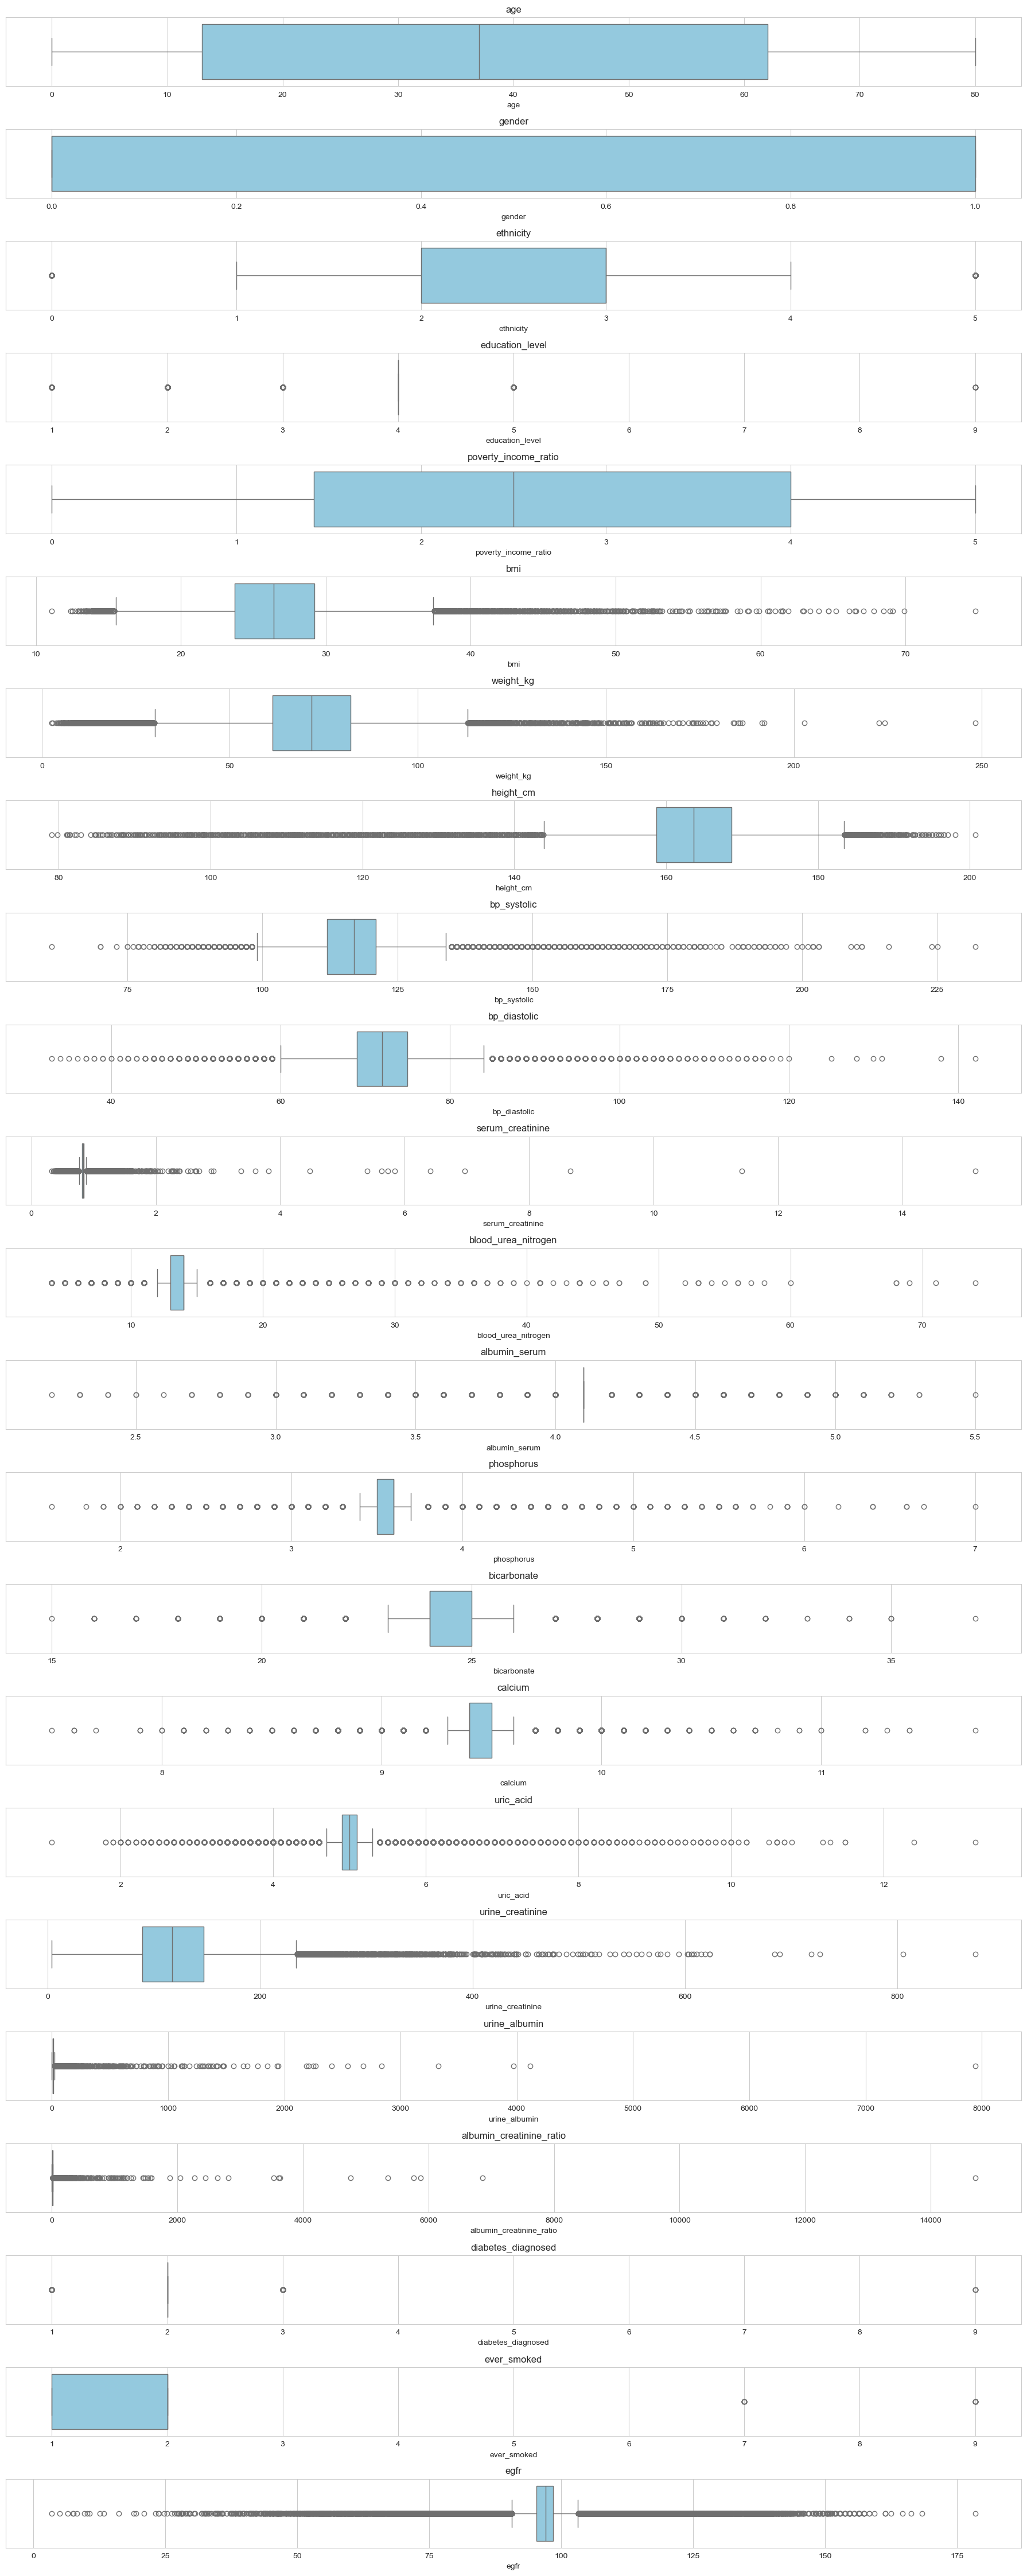

In [52]:
# Boxplots for Numerical Features

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18, 45))

for i, column in enumerate(numerical_columns):

    plt.subplot(len(numerical_columns), 1, i + 1)

    sns.boxplot(x=X[column], color="skyblue")

    plt.title(column)

plt.tight_layout()

plt.show()

In [53]:
# Count Outliers Using IQR

outlier_summary = {}

for column in numerical_columns:

    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = X[(X[column] < lower) | (X[column] > upper)]

    outlier_summary[column] = len(outliers)

outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=["Feature", "Number of Outliers"]
)

outlier_df.sort_values(
    by="Number of Outliers",
    ascending=False
)

,Feature,Number of Outliers
12,albumin_serum,5595
3,education_level,5424
16,uric_acid,5083
10,serum_creatinine,4870
22,egfr,4853
13,phosphorus,4510
11,blood_urea_nitrogen,4097
15,calcium,3652
14,bicarbonate,2465
8,bp_systolic,2096


In [54]:
continuous_columns = [
    'age',
    'poverty_income_ratio',
    'bmi',
    'weight_kg',
    'height_cm',
    'bp_systolic',
    'bp_diastolic',
    'serum_creatinine',
    'blood_urea_nitrogen',
    'albumin_serum',
    'phosphorus',
    'bicarbonate',
    'calcium',
    'uric_acid',
    'urine_creatinine',
    'urine_albumin',
    'albumin_creatinine_ratio',
    'egfr'
]

iqr_bounds = {}

X_capped = X.copy()

for column in continuous_columns:

    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_bounds[column] = {
        "lower": lower,
        "upper": upper
    }

    X_capped[column] = X_capped[column].clip(
        lower=lower,
        upper=upper
    )

X_capped.describe().T

,count,mean,std,min,25%,50%,75%,max
age,11933.0,38.317858,2.560199e+01,5.397605e-79,13.00,37.00,62.00,80.000
gender,11933.0,0.467192,4.989434e-01,0.000000e+00,0.00,0.00,1.00,1.000
ethnicity,11933.0,2.745160,1.254026e+00,0.000000e+00,2.00,3.00,3.00,5.000
education_level,11933.0,3.872622,9.370206e-01,1.000000e+00,4.00,4.00,4.00,9.000
poverty_income_ratio,11933.0,2.672569,1.522605e+00,5.397605e-79,1.42,2.50,4.00,5.000
bmi,11933.0,26.568294,5.599844e+00,1.545000e+01,23.70,26.40,29.20,37.450
weight_kg,11933.0,71.085123,2.143779e+01,3.010000e+01,61.30,71.70,82.10,113.300
height_cm,11933.0,163.167942,1.004570e+01,1.438500e+02,158.70,163.60,168.60,183.450
bp_systolic,11933.0,117.134585,9.938715e+00,9.850000e+01,112.00,117.00,121.00,134.500
bp_diastolic,11933.0,72.049359,6.721870e+00,6.000000e+01,69.00,72.00,75.00,84.000


In [55]:
joblib.dump(iqr_bounds, "iqr_bounds.pkl")

['iqr_bounds.pkl']

In [56]:
# Initialize StandardScaler
scaler = StandardScaler()

# Scale all features
X_scaled = scaler.fit_transform(X_capped)

In [57]:
# Convert scaled data back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_capped.columns
)

X_scaled.head()

,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,...,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,ever_smoked,egfr
0,0.182890,1.067918,-1.391705,1.203202,1.528649,0.077096,0.737741,1.625844,1.747323,1.777949,...,0.920977,-0.226652,1.450963,0.356537,0.250049,1.831784,1.703620,0.181074,-1.485184,1.482138
1,1.081295,1.067918,0.203226,1.203202,1.528649,1.237891,1.432805,1.098233,0.388941,1.777949,...,-1.733799,0.668182,-0.167124,1.471755,-1.007797,-1.168038,-0.581639,0.181074,-1.485184,0.235727
2,0.221951,-0.936402,1.000691,-0.931312,-0.829251,0.559272,-0.078609,-1.022166,-0.617267,1.034077,...,1.300230,0.668182,-0.167124,-1.502160,0.616921,0.332331,-0.299290,-2.628749,0.534727,1.482138
3,-1.301432,-0.936402,1.798156,0.135945,-0.750435,-0.494373,-1.715973,-1.923086,-0.013542,-0.007343,...,0.162469,-0.226652,-0.167124,-0.015202,1.507896,1.009148,-0.336789,0.181074,0.534727,0.008672
4,-1.418615,1.067918,0.203226,0.135945,0.609134,-0.030055,-1.911897,0.043011,-0.013542,-0.007343,...,0.162469,-0.226652,-0.167124,-0.015202,-0.081882,-0.183077,-0.222085,0.181074,0.534727,0.008672


In [58]:
# Summary statistics after scaling
X_scaled.describe().round(2)

,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,...,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,ever_smoked,egfr
count,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,...,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00
mean,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,...,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.50,-0.94,-2.19,-3.07,-1.76,-1.99,-1.91,-1.92,-1.88,-1.79,...,-1.73,-1.57,-1.38,-1.50,-2.06,-1.91,-2.03,-2.63,-1.49,-1.51
25%,-0.99,-0.94,-0.59,0.14,-0.82,-0.51,-0.46,-0.44,-0.52,-0.45,...,-0.60,-0.23,-0.17,-0.39,-0.57,-0.58,-0.59,0.18,-1.49,-0.39
50%,-0.05,-0.94,0.20,0.14,-0.11,-0.03,0.03,0.04,-0.01,-0.01,...,0.16,-0.23,-0.17,-0.02,-0.08,-0.18,-0.22,0.18,0.53,0.01
75%,0.93,1.07,0.20,0.14,0.87,0.47,0.51,0.54,0.39,0.44,...,0.16,0.67,0.64,0.36,0.44,0.39,0.40,0.18,0.53,0.36
max,1.63,1.07,1.80,5.47,1.53,1.94,1.97,2.02,1.75,1.78,...,1.30,2.01,1.86,1.47,1.96,1.83,1.87,19.85,14.67,1.48


In [59]:
comparison = pd.DataFrame({
    "Original Mean": X_capped.mean(),
    "Scaled Mean": X_scaled.mean(),
    "Original Std": X_capped.std(),
    "Scaled Std": X_scaled.std()
})

comparison.round(2)

,Original Mean,Scaled Mean,Original Std,Scaled Std
age,38.32,0.0,25.60,1.0
gender,0.47,0.0,0.50,1.0
ethnicity,2.75,-0.0,1.25,1.0
education_level,3.87,0.0,0.94,1.0
poverty_income_ratio,2.67,0.0,1.52,1.0
bmi,26.57,0.0,5.60,1.0
weight_kg,71.09,-0.0,21.44,1.0
height_cm,163.17,0.0,10.05,1.0
bp_systolic,117.13,-0.0,9.94,1.0
bp_diastolic,72.05,-0.0,6.72,1.0


## Boruta-Feature Selection

In [60]:
# Random Forest for Boruta

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [61]:
boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    random_state=42,
    verbose=2
)

In [62]:
boruta_selector.fit(
    X_scaled.values,
    y.values
)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	16
Tentative: 	2
Rejected: 	5
Iteration: 	9 / 100
Confirmed: 	16
Tentative: 	2
Rejected: 	5
Iteration: 	10 / 100
Confirmed: 	16
Tentative: 	2
Rejected: 	5
Iteration: 	11 / 100
Confirmed: 	16
Tentative: 	2
Rejected: 	5
Iteration: 	12 / 100
Confirmed: 	16
Tentative: 	2
Rejected: 	5
Iteration: 	13 / 100
Confirmed: 	16
Tentative: 	2
Rejected: 	5
Iteration: 	14 / 100
Confirmed: 	16
Tentative: 	2
Rejected: 	5
Iteration: 	15 / 100
Confirmed: 	16
Tentative: 	2
Rejected: 	5
Iteration: 	16 / 100
Confirmed: 	16
Tentative: 	2
Rejected: 	5
I

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced',
                                          n_estimators=60, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x1CD4C9CBB40),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x1CD4C9CBB40, verbose=2)

In [63]:
selected_features = X_scaled.columns[
    boruta_selector.support_
]

print("Selected Features:")
print(selected_features.tolist())

Selected Features:
['age', 'gender', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic', 'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'egfr']


In [64]:
print(f"Total Selected Features: {len(selected_features)}")

Total Selected Features: 17


In [65]:
rejected_features = X_scaled.columns[
    ~boruta_selector.support_
]

print("Rejected Features:")
print(rejected_features.tolist())

Rejected Features:
['ethnicity', 'education_level', 'poverty_income_ratio', 'albumin_serum', 'diabetes_diagnosed', 'ever_smoked']


In [66]:
feature_ranking = pd.DataFrame({
    "Feature": X_scaled.columns,
    "Ranking": boruta_selector.ranking_
})

feature_ranking = feature_ranking.sort_values("Ranking")

feature_ranking

,Feature,Ranking
0,age,1
1,gender,1
6,weight_kg,1
5,bmi,1
7,height_cm,1
10,serum_creatinine,1
9,bp_diastolic,1
8,bp_systolic,1
13,phosphorus,1
14,bicarbonate,1


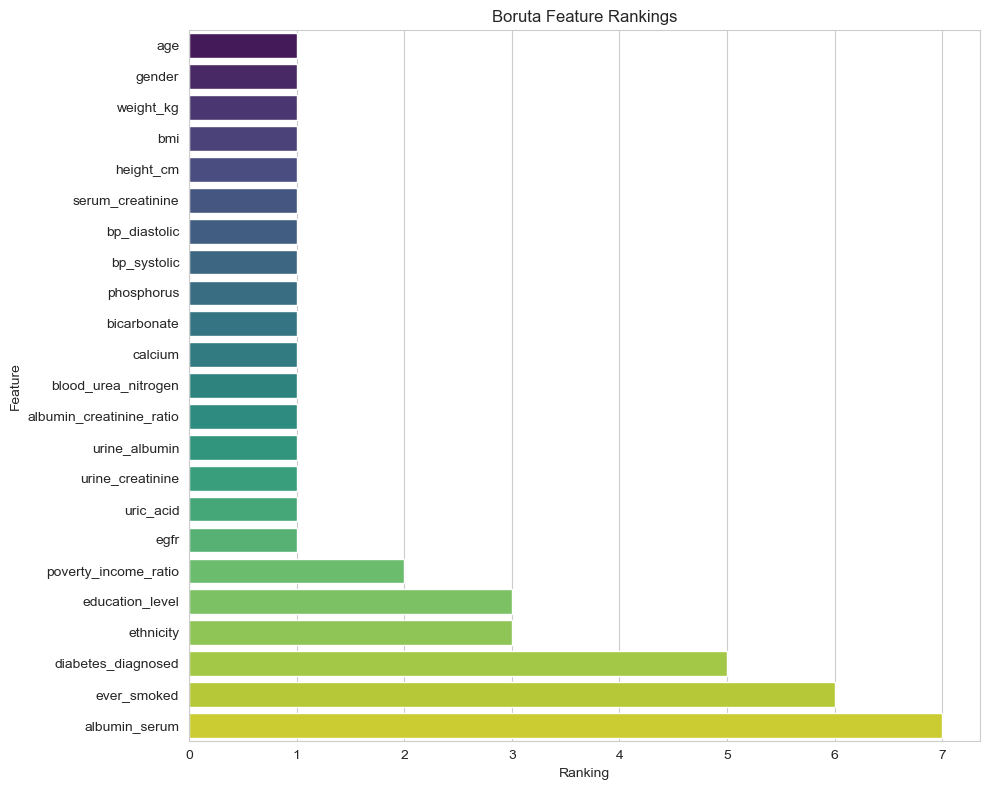

In [67]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_ranking,
    x="Ranking",
    y="Feature",
    palette="viridis"
)

plt.title("Boruta Feature Rankings")

plt.tight_layout()

plt.show()

In [68]:
X_selected = X_scaled[selected_features]

print("Original Shape:", X_scaled.shape)
print("Selected Shape:", X_selected.shape)

Original Shape: (11933, 23)
Selected Shape: (11933, 17)


In [69]:
import joblib

joblib.dump(
    selected_features.tolist(),
    "selected_features.pkl"
)

print("Selected features saved successfully.")

Selected features saved successfully.


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Set: (9546, 17)
Testing Set : (2387, 17)
Training Labels: (9546,)
Testing Labels : (2387,)


In [71]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [72]:
# Model Evaluation Function
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities (if supported)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Specificity
    specificity = tn / (tn + fp)

    # Metrics
    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Specificity": specificity,
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    return results

In [73]:
# Machine Learning Models

models = {

    "Logistic Regression":
        LogisticRegression(random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
}

In [74]:
# Train and Evaluate Models

results = []
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

    metrics = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

print("All models trained successfully!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training KNN...
Training Naive Bayes...
Training SVM...
Training XGBoost...
All models trained successfully!


In [75]:
results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1-Score",
        "ROC-AUC"
    ]
]

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC
6,XGBoost,0.9786,0.9815,0.9880,0.9569,0.9848,0.9977
2,Random Forest,0.9778,0.9792,0.9892,0.9513,0.9842,0.9975
5,SVM,0.9585,0.9574,0.9844,0.8985,0.9707,0.9860
3,KNN,0.9342,0.9473,0.9592,0.8762,0.9532,0.9708
1,Decision Tree,0.9686,0.9767,0.9784,0.9458,0.9775,0.9621
4,Naive Bayes,0.8869,0.9605,0.8741,0.9166,0.9153,0.9598
0,Logistic Regression,0.9133,0.9134,0.9676,0.7872,0.9397,0.9289


In [76]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

joblib.dump(best_model, "best_model.pkl")

print(f"{best_model_name} saved successfully!")

XGBoost saved successfully!


## Model Evaluation

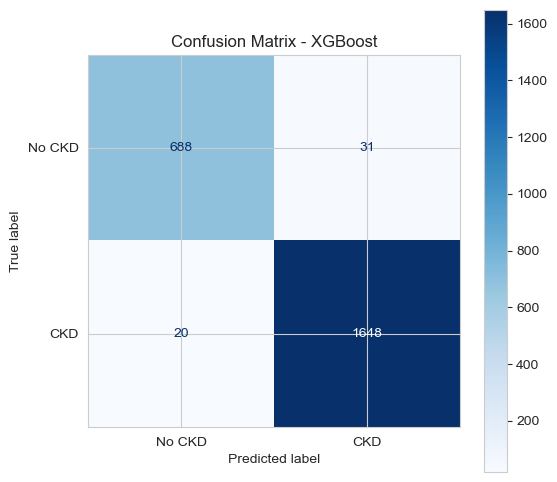

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay

# Get the trained XGBoost model
xgb_model = trained_models["XGBoost"]

# Predictions
y_pred = xgb_model.predict(X_test)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    display_labels=["No CKD", "CKD"],
    ax=ax
)

plt.title("Confusion Matrix - XGBoost")
plt.show()

In [78]:
# Classification report

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No CKD", "CKD"]
))

              precision    recall  f1-score   support

      No CKD       0.97      0.96      0.96       719
         CKD       0.98      0.99      0.98      1668

    accuracy                           0.98      2387
   macro avg       0.98      0.97      0.97      2387
weighted avg       0.98      0.98      0.98      2387



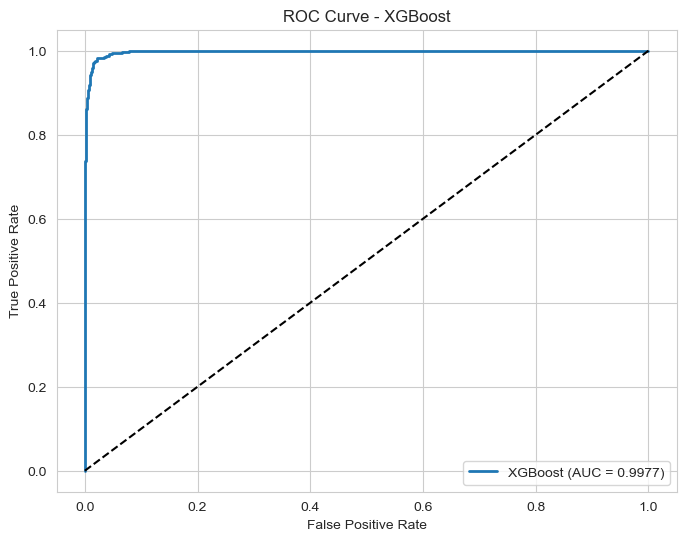

In [79]:
from sklearn.metrics import roc_curve, auc

# Prediction probabilities
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.4f})",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

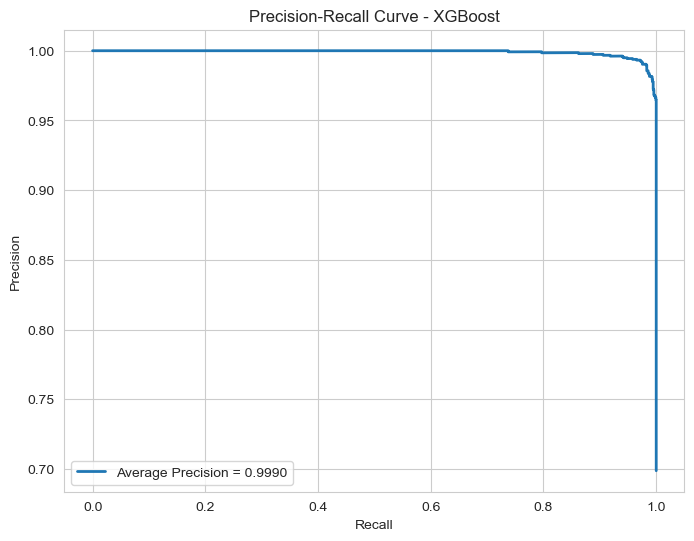

In [80]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Predict probabilities
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Precision-Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Average Precision Score
average_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Average Precision = {average_precision:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")

plt.legend()

plt.grid(True)

plt.show()

In [81]:
# 10-fold stratified CV
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_model,
    X_selected,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross Validation Scores")
print(scores)

print("\nMean Accuracy:", scores.mean())

print("Standard Deviation:", scores.std())

Cross Validation Scores
[0.9681742  0.98324958 0.97822446 0.98072087 0.98155909 0.97904443
 0.97988265 0.98323554 0.97150042 0.97569153]

Mean Accuracy: 0.9781282775992283
Standard Deviation: 0.004729483432298954


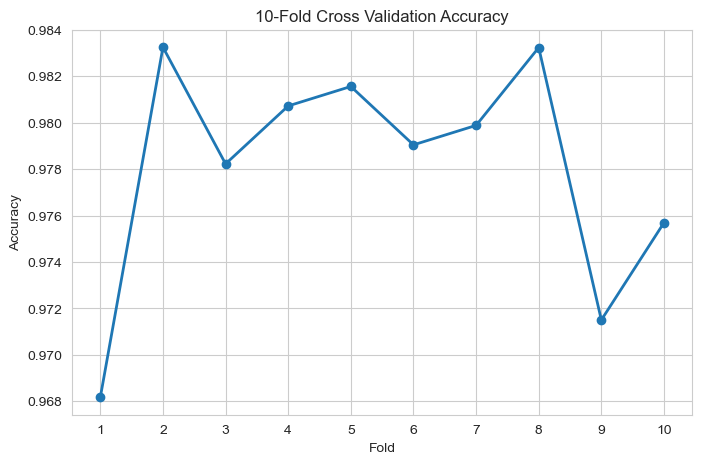

In [82]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    scores,
    marker="o",
    linewidth=2
)

plt.xticks(range(1,11))

plt.xlabel("Fold")

plt.ylabel("Accuracy")

plt.title("10-Fold Cross Validation Accuracy")

plt.grid(True)

plt.show()

In [83]:
# Hyperparameter Tuning
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [84]:
grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='roc_auc', verbose=2)

In [85]:
print("Best Parameters")

print(grid_search.best_params_)

print("\nBest ROC-AUC")

print(grid_search.best_score_)

Best Parameters
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}

Best ROC-AUC
0.9974534730803075


In [86]:
best_xgb = grid_search.best_estimator_

In [87]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_selected.columns,
    "Importance": best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
16,egfr,0.597551
7,serum_creatinine,0.115985
15,albumin_creatinine_ratio,0.068585
4,height_cm,0.047951
8,blood_urea_nitrogen,0.043012
12,uric_acid,0.029934
0,age,0.021494
14,urine_albumin,0.017688
1,gender,0.015658
10,bicarbonate,0.012955


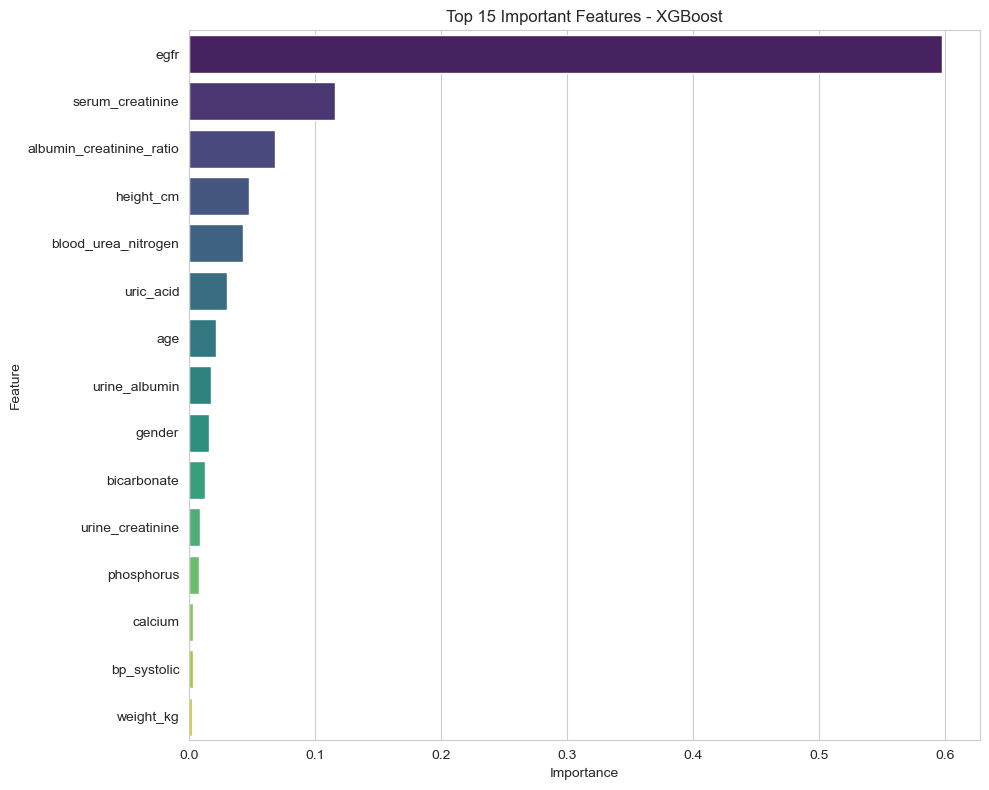

In [88]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Important Features - XGBoost")

plt.tight_layout()

plt.show()

## SHAP Explainability

In [89]:
# Create SHAP explainer
explainer = shap.TreeExplainer(best_xgb)

In [90]:
# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

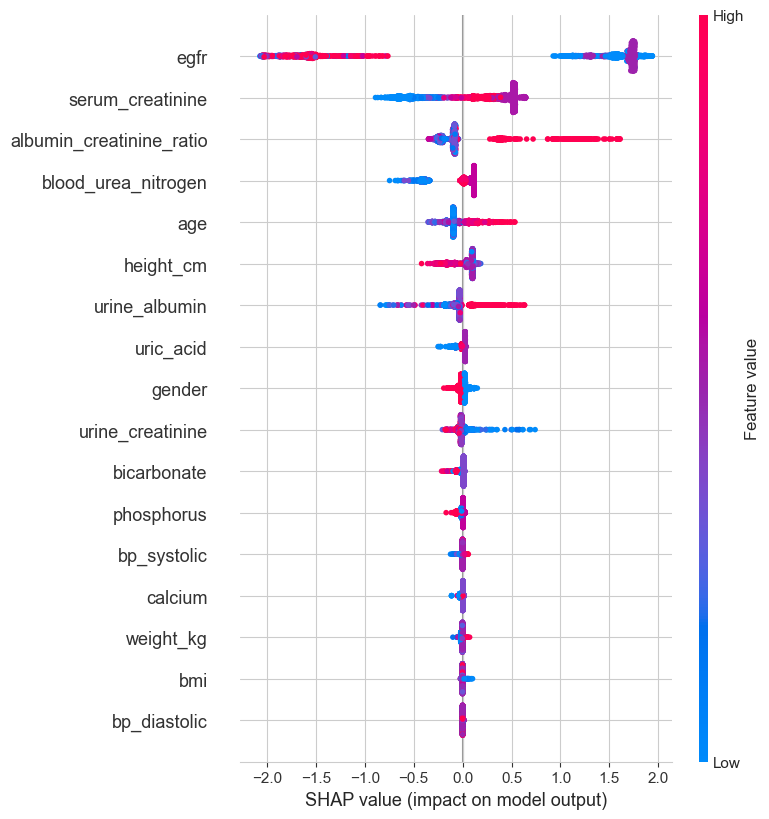

In [91]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.show()

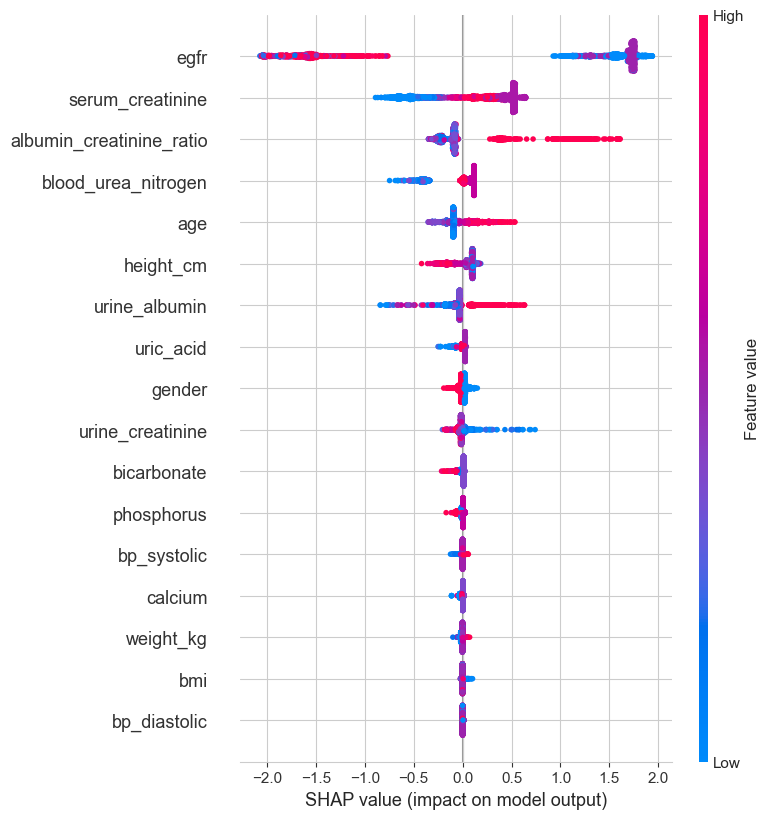

In [92]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.show()

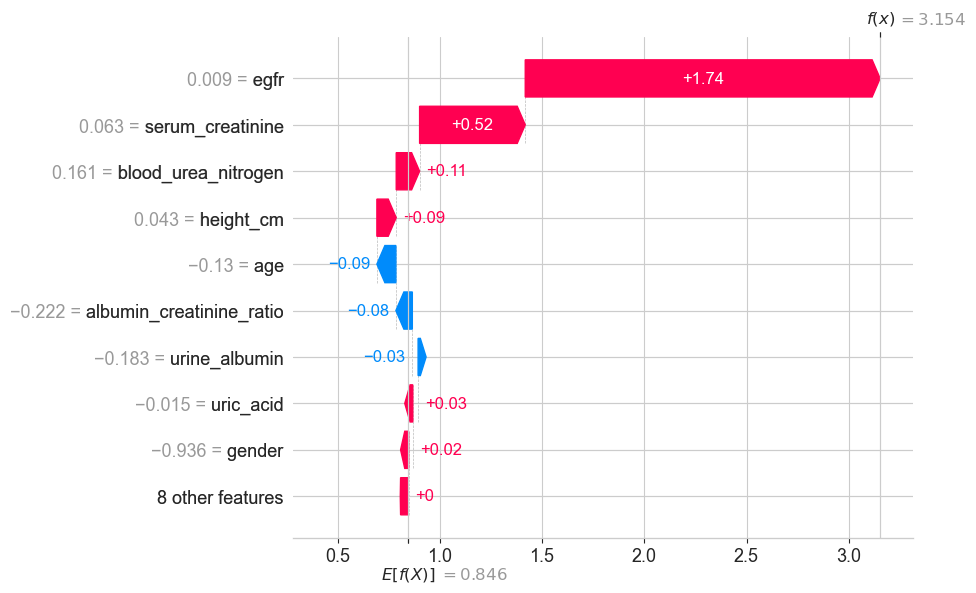

In [93]:
# Explain the first test sample
shap.plots.waterfall(
    explainer(X_test.iloc[[0]])[0]
)

In [94]:
patient_data = {
    "age": 40,
    "gender": 1,
    "ethnicity": 3,
    "education_level": 3,
    "poverty_income_ratio": 2.0,
    "bmi": 22.0,
    "weight_kg": 70.0,
    "height_cm": 170.0,
    "bp_systolic": 120.0,
    "bp_diastolic": 80.0,
    "serum_creatinine": 1.0,
    "blood_urea_nitrogen": 15.0,
    "albumin_serum": 4.0,
    "phosphorus": 3.5,
    "bicarbonate": 24.0,
    "calcium": 9.5,
    "uric_acid": 5.0,
    "urine_creatinine": 100.0,
    "urine_albumin": 20.0,
    "albumin_creatinine_ratio": 30.0,
    "diabetes_diagnosed": 2,
    "ever_smoked": 2,
    "egfr": 95.0
}

In [95]:
input_data = pd.DataFrame([patient_data])

In [96]:
scaler_features = list(scaler.feature_names_in_)

input_data = input_data[scaler_features]

for column, bounds in iqr_bounds.items():
    if column in input_data.columns:
        input_data[column] = input_data[column].clip(
            lower=bounds["lower"],
            upper=bounds["upper"]
        )

In [97]:
print(input_data.T)

                                0
age                        40.000
gender                      1.000
ethnicity                   3.000
education_level             3.000
poverty_income_ratio        2.000
bmi                        22.000
weight_kg                  70.000
height_cm                 170.000
bp_systolic               120.000
bp_diastolic               80.000
serum_creatinine            0.885
blood_urea_nitrogen        15.000
albumin_serum               4.100
phosphorus                  3.500
bicarbonate                24.000
calcium                     9.500
uric_acid                   5.000
urine_creatinine          100.000
urine_albumin              20.000
albumin_creatinine_ratio   17.760
diabetes_diagnosed          2.000
ever_smoked                 2.000
egfr                       95.000


In [98]:
input_scaled = scaler.transform(input_data)

input_scaled = pd.DataFrame(
    input_scaled,
    columns=scaler_features
)

model_input = input_scaled[selected_features]

prediction = model.predict(model_input)[0]

probabilities = model.predict_proba(model_input)[0]

print("Prediction:", prediction)
print(f"No CKD Probability: {probabilities[0] * 100:.2f}%")
print(f"CKD Probability: {probabilities[1] * 100:.2f}%")

Prediction: 0
No CKD Probability: 83.08%
CKD Probability: 16.92%


In [99]:
print(list(iqr_bounds.keys()))


['age', 'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic', 'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'egfr']


In [100]:
print(selected_features)


Index(['age', 'gender', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic',
       'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen', 'phosphorus',
       'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine',
       'urine_albumin', 'albumin_creatinine_ratio', 'egfr'],
      dtype='object')


In [101]:
import joblib

joblib.dump(model, "best_xgboost_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(selected_features, "selected_features.pkl")
joblib.dump(iqr_bounds, "iqr_bounds.pkl")

print("All files saved successfully.")


All files saved successfully.
